<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/BQm_EV6i0_j80CQZ8vcLvw/SN-web-lightmode.png" width=300 height=300 />


## Lab: Practical Application of Transpose Convolution  

**Estimated time needed: 30 minutes**

This lab will guide you through creating, training, and evaluating models that use transpose convolution layers for tasks such as image reconstruction. 

##### Learning objectives: 

By the end of this lab, you will: 

- Apply transpose convolution in practical scenarios using Keras.  

- Create, compile, train, and evaluate the model 

- Visualize the results  

##### Prerequisites: 

- Basic understanding of Python programming 

- Familiarity with convolutional neural network (CNN) concepts 

- Keras and TensorFlow installed 




#### Steps: 
**Step 1: Import Necessary Libraries**

Before you start, make sure to import the required libraries: TensorFlow and Keras. Keras is included within TensorFlow as `tensorflow.keras`. 


In [1]:
import warnings
warnings.simplefilter('ignore')

!pip install tensorflow==2.16.2 

!pip install matplotlib 

!pip install pandas

import pandas as pd
import tensorflow as tf 

from tensorflow.keras.models import Model 

from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, UpSampling2D 

import numpy as np 

import matplotlib.pyplot as plt 


  Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 115.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 155.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 94.9 MB/s eta 0:00:00


2026-05-03 17:29:36.516781: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-03 17:29:36.518124: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-03 17:29:36.523261: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-03 17:29:36.539137: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-03 17:29:36.596407: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

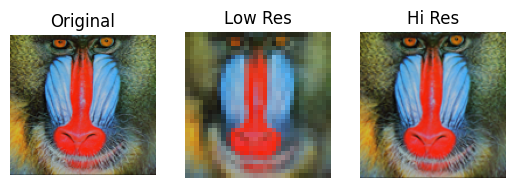

In [33]:
from PIL import Image
import requests 
import matplotlib.pyplot as plt
from io import BytesIO

#Read baboon image from github repo
url = 'https://raw.githubusercontent.com/idealo/image-super-resolution/master/data/input/sample/baboon.png'

response = requests.get(url)

img = Image.open(BytesIO(response.content)).convert("RGB")

img_high_res = img.resize((128, 128))

img_low_res = img.resize((32, 32))

# Plot Original and Low Res image
plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Low Res")
plt.imshow(img_low_res)
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Hi Res")
plt.imshow(img_high_res)
plt.axis('off')


plt.show()

In [38]:
X_train = np.array(img_low_res)/255.0
y_train = np.array(img_high_res)/255.0

X_train = X_train.reshape(1,32,32,3)
y_train = y_train.reshape(1,128,128,3)

input_layer = Input(shape=(32,32,3))

x = Conv2D(64, (3, 3), activation='relu', padding='same')(input_layer) 

x = UpSampling2D(size=(2,2))(x)   # 32 → 64

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x) 

x = UpSampling2D(size=(2,2))(x)   # 64 → 128

x = Conv2D(32, (3,3), activation='relu', padding='same')(x) 

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)

output_layer = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

model = Model(inputs=input_layer, outputs=output_layer)

model.compile(optimizer='adam', loss='mae')

history = model.fit(X_train, y_train, epochs=1000, batch_size=1) 

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.2032
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.1969
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 0.1907
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 0.1869
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 0.1840
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 0.1803
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 0.1757
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 0.1714
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.1664
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.1605
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 0.1550
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.1491
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 0.1435
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 0.1387
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


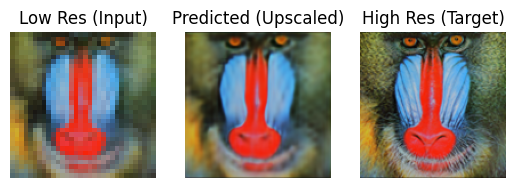

In [39]:
pred = model.predict(X_train)

# Low-res input
plt.subplot(1,3,1)
plt.title("Low Res (Input)")
plt.imshow(X_train[0])
plt.axis('off')

# Model output
plt.subplot(1,3,2)
plt.title("Predicted (Upscaled)")
plt.imshow((pred[0] * 255).astype('uint8'))
plt.axis('off')

# Ground truth
plt.subplot(1,3,3)
plt.title("High Res (Target)")
plt.imshow(y_train[0])
plt.axis('off')

plt.show()

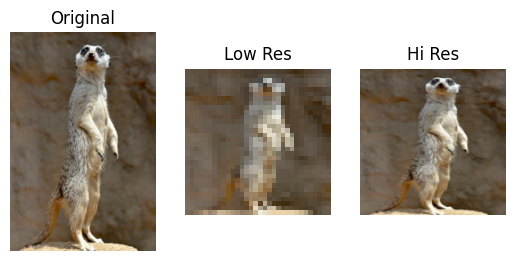

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


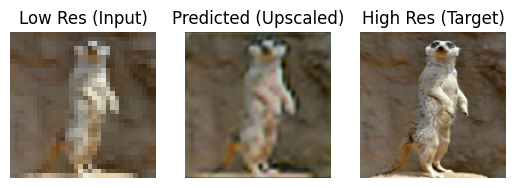

In [43]:
#Read baboon image from github repo
url = 'https://raw.githubusercontent.com/idealo/image-super-resolution/master/data/input/sample/meerkat.png'

response = requests.get(url)

img = Image.open(BytesIO(response.content)).convert("RGB")

img_high_res = img.resize((128, 128))

img_low_res = img.resize((32, 32))

# Plot Original and Low Res image
plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Low Res")
plt.imshow(img_low_res)
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Hi Res")
plt.imshow(img_high_res)
plt.axis('off')


plt.show()

X_test= np.array(img_low_res)/255.0
y_test = np.array(img_high_res)/255.0

X_test = X_test.reshape(1,32,32,3)
y_test = y_test.reshape(1,128,128,3)

pred = model.predict(X_test)

# Low-res input
plt.subplot(1,3,1)
plt.title("Low Res (Input)")
plt.imshow(X_test[0])
plt.axis('off')

# Model output
plt.subplot(1,3,2)
plt.title("Predicted (Upscaled)")
plt.imshow((pred[0] * 255).astype('uint8'))
plt.axis('off')

# Ground truth
plt.subplot(1,3,3)
plt.title("High Res (Target)")
plt.imshow(y_test[0])
plt.axis('off')

plt.show()


**Explanation:**

 `tensorflow` is the main library for machine learning in Python. 

  `Model, Input, Conv2D, and Conv2DTranspose` are used to create and manipulate the layers in your model. 

  `numpy` and `matplotlib` are used for data manipulation and visualization. 

 
**Step 2: Define the Input Layer**

You need to define the input shape for your model. For simplicity, let's assume you are working with an input image of size 28x28 with 1 channel (grayscale). 

 


In [44]:
input_layer = Input(shape=(28, 28, 1))

**Explanation:**

`Input(shape=(28, 28, 1))` creates an input layer that expects 28x28 grayscale images.


**Step 3: Add convolutional and transpose convolutional layers**

You will add a convolutional layer to extract features, followed by a transpose convolution layer to reconstruct the image. 


In [45]:
conv_layer = Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(input_layer) 

transpose_conv_layer = Conv2DTranspose(filters=1, kernel_size=(3, 3), activation='sigmoid', padding='same')(conv_layer) 


**Explanation:**

`Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')` creates a convolution layer with 32 filters. 

`Conv2DTranspose(filters=1, kernel_size=(3, 3), activation='sigmoid', padding='same')` creates a transpose convolution layer for reconstructing the image. 

**Step 4: Create the Model**

Now, you will create the model by specifying the input and output layers.


In [46]:
model = Model(inputs=input_layer, outputs=transpose_conv_layer)

**Explanation:**

`Model(inputs=input_layer, outputs=transpose_conv_layer)` creates a Keras model that connects the input layer to the output layer through the convolutional and transpose convolutional layers.  

**Step 5: Compile the Model**

Before training the model, you need to compile it. You will specify the loss function, optimizer, and evaluation metrics. 


In [47]:
model.compile(optimizer='adam', loss='mean_squared_error')

**Explanation:**

- optimizer=`adam` specifies the Adam optimizer. 

- loss=`mean_squared_error` specifies the mean squared error loss function.  


**Step 6: Train the Model**

You can now train the model on some training data. For this example, let's assume X_train is our training input data.


In [48]:
# Generate synthetic training data 

X_train = np.random.rand(1000, 28, 28, 1) 

y_train = X_train # For reconstruction, the target is the input 

history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2) 

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0738 - val_loss: 0.0623
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0496 - val_loss: 0.0360
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0264 - val_loss: 0.0180
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0133 - val_loss: 0.0093
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0073 - val_loss: 0.0056
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0048 - val_loss: 0.0040
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0036 - val_loss: 0.0032
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0030 - val_loss: 0.0027
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0026 - val_loss: 0.0024
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0023 - val_loss: 0.0022


**Explanation:**

- X_train is a placeholder for your actual training data. 

- y_train is the same as X_train for image reconstruction. 

- model.fit trains the model for a specified number of epochs and batch size.

  
**Step 7: Evaluate the Model**

After training, you can evaluate the model on test data to see how well it performs. 


In [49]:
 # Generate synthetic test data 

X_test = np.random.rand(200, 28, 28, 1) 

y_test = X_test 

loss = model.evaluate(X_test, y_test) 

print(f'Test loss: {loss}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0022
Test loss: 0.0021655408199876547


**Explanation:**

`X_test` and `y_test` are placeholders for your actual test data. 

`model.evaluate` computes the loss of the model on test data. . 

**Step 8: Visualize the Results**

To better understand the model's performance, let's visualize some reconstructed images.  


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


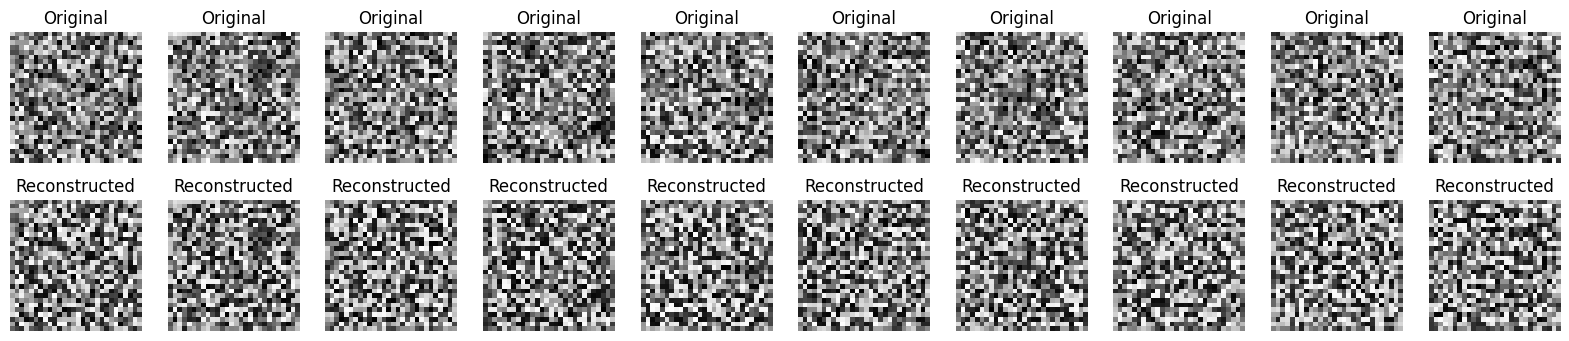

In [50]:
# Predict on test data 
y_pred = model.predict(X_test) 

# Plot some sample images 

n = 10 # Number of samples to display 

plt.figure(figsize=(20, 4))

for i in range(n): 

    # Display original 
    ax = plt.subplot(2, n, i + 1) 
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original") 
    plt.axis('off') 
    # Display reconstruction 
    ax = plt.subplot(2, n, i + 1 + n) 
    plt.imshow(y_pred[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show() 

**Explanation:**

`model.predict` generates predictions for the test data. 

`plt.imshow` visualizes the original and reconstructed images side by side for comparison. 


### Practice exercises


#### Exercise 1: Experiment with Different Kernel Sizes 

**Objective:** Understand the impact of different kernel sizes on the model's performance. 

**Instructions:**
1. Modify the kernel size of the `Conv2D` and `Conv2DTranspose` layers. 
2. Recompile, train, and evaluate the model. 
3. Observe and record the differences in performance.


In [ ]:
# Write your code here

<details>
<summary>Click here for solution</summary> </br>

```python
from tensorflow.keras.layers import Dropout, Conv2D, Conv2DTranspose, Input
from tensorflow.keras.models import Model

# Define the input layer
input_layer = Input(shape=(28, 28, 1))

# Add convolutional and transpose convolutional layers with different kernel sizes
conv_layer = Conv2D(filters=32, kernel_size=(5, 5), activation='relu', padding='same')(input_layer)
transpose_conv_layer = Conv2DTranspose(filters=1, kernel_size=(5, 5), activation='sigmoid', padding='same')(conv_layer)

# Create the model
model = Model(inputs=input_layer, outputs=transpose_conv_layer)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')


#### Exercise 2: Add Dropout Layers

**Objective:** Add dropout layers to prevent overfitting.

**Instructions:**
1. Add dropout layers after the convolutional layer. 
2. Set the dropout rate to 0.5.
3. Recompile, train, and evaluate the model.


In [ ]:
# Write your code here

<details>
<summary>Click here for solution</summary> </br>

```python
from tensorflow.keras.layers import Dropout, Conv2D, Conv2DTranspose, Input
from tensorflow.keras.models import Model

# Define the input layer
input_layer = Input(shape=(28, 28, 1))

# Add convolutional, dropout, and transpose convolutional layers
conv_layer = Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(input_layer)
dropout_layer = Dropout(0.5)(conv_layer)
transpose_conv_layer = Conv2DTranspose(filters=1, kernel_size=(3, 3), activation='sigmoid', padding='same')(dropout_layer)

# Create the model
model = Model(inputs=input_layer, outputs=transpose_conv_layer)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')


#### Exercise 3: Use Different Activation Functions 

**Objective:** Experiment with different activation functions and observe their impact on model performance. 

**Instructions:**
1. Change the activation function of the convolutional and transpose convolutional layers to `tanh`. 
2. Recompile, train, and evaluate the model.


In [ ]:
# Write your code here

<details>
<summary>Click here for solution</summary> </br>

```python

from tensorflow.keras.layers import Conv2D, Conv2DTranspose, Input
from tensorflow.keras.models import Model

# Define the input layer
input_layer = Input(shape=(28, 28, 1))

# Add convolutional and transpose convolutional layers with different activation functions
conv_layer = Conv2D(filters=32, kernel_size=(3, 3), activation='tanh', padding='same')(input_layer)
transpose_conv_layer = Conv2DTranspose(filters=1, kernel_size=(3, 3), activation='tanh', padding='same')(conv_layer)

# Create the model
model = Model(inputs=input_layer, outputs=transpose_conv_layer)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')



### Conclusion:

By completing this lab, you have successfully created, trained, and evaluated a simple neural network model using transpose convolution for image reconstruction. This exercise provided hands-on experience with Keras and practical applications of transpose convolution layers. Continue experimenting with different architectures and datasets to deepen your understanding and skills in deep learning with Keras. 


Copyright © IBM Corporation. All rights reserved.
